# 🎓 Maze Flow Matching + CBF 完整教学Notebook

**目标**: 通过本notebook学习如何使用Flow Matching生成迷宫导航轨迹，并应用Control Barrier Function (CBF)确保安全性。

---

## 📚 第一部分：理论基础

### 1.1 Flow Matching 是什么？

Flow Matching是一种**生成模型**，它学习如何将随机噪声转换成有意义的数据（如轨迹）。

**核心思想**：
- 训练时：观察数据分布 $p_1$ (真实轨迹)
- 推理时：从噪声 $p_0 \sim \mathcal{N}(0, I)$ 开始
- 通过学习的速度场 $v_\theta(x, t)$ 演化到数据分布

**数学表达**：
$$\frac{dx}{dt} = v_\theta(x, t), \quad t \in [0, 1]$$

其中：
- $x \in \mathbb{R}^{2 \times 100}$: 轨迹状态（2D坐标×100个时间步）
- $v_\theta$: 神经网络学习的速度场
- $t$: 归一化时间，从0（噪声）到1（数据）

**为什么叫Flow Matching？**
- **Flow**: 数据在速度场的"驱动"下流动
- **Matching**: 学习的目标是让流动后的分布匹配真实数据分布

---

### 1.2 Control Barrier Function (CBF) 是什么？

CBF是一种**安全保证机制**，确保系统永远不会进入危险区域。

**核心思想**：定义一个"安全函数" $h(x)$：
- $h(x) > 0$: **Safe** (安全区域，远离障碍物)
- $h(x) = 0$: **Boundary** (边界)
- $h(x) < 0$: **Unsafe** (危险区域，在障碍物内部)

**CBF条件**（确保安全）：
$$\frac{dh}{dt} = \nabla h(x) \cdot v(x) \geq -\alpha(h(x))$$

**直观理解**：
- $\nabla h$: 指向"更安全"方向的梯度
- $\nabla h \cdot v$: 速度在安全方向上的投影
- 条件要求：速度不能让我们"快速冲向危险"

**本notebook中的障碍物：椭圆**

对于椭圆障碍物，我们定义：
$$h(x) = \left(\frac{x_{\text{rot}}}{a}\right)^2 + \left(\frac{y_{\text{rot}}}{b}\right)^2 - 1$$

其中：
- $(x_{\text{rot}}, y_{\text{rot}}) = R^{-1}(x - c)$: 旋转到椭圆局部坐标系
- $R$: 旋转矩阵（考虑椭圆的角度）
- $c$: 椭圆中心坐标
- $a, b$: 椭圆的半长轴和半短轴

---

### 1.3 如何结合Flow Matching和CBF？

**挑战**：Flow Matching生成的轨迹可能穿过障碍物（因为训练数据可能不够完美）

**解决方案**：在ODE求解的每一步，修正速度场：

1. **原始速度**: $v_{\text{nom}} = v_\theta(x, t)$ （神经网络预测）
2. **CBF投影**: $v_{\text{safe}} = \text{Project}(v_{\text{nom}}, h, \nabla h)$ （修正后的安全速度）
3. **使用安全速度**: $\frac{dx}{dt} = v_{\text{safe}}$

**时间门控策略**（重要！）：

不是一直应用CBF，而是分阶段：
- **早期** $(t < 0.5T)$: CBF完全关闭，让Flow自由演化
- **中期** $(0.5T \leq t \leq 0.8T)$: 平滑过渡，逐渐增强CBF
- **后期** $(t > 0.8T)$: CBF完全激活，强力避障

**为什么这样设计？**
- 早期：轨迹还在噪声空间，没必要避障
- 后期：轨迹接近真实空间，需要确保安全

---

## 🎯 本Notebook的学习路径

1. **环境准备** → 导入库、定义迷宫
2. **模型定义** → 理解Flow Matching架构
3. **加载权重** → 使用预训练模型
4. **基础推理** → 生成无CBF的轨迹
5. **CBF实现** → 添加安全约束
6. **对比实验** → 可视化CBF的效果
7. **参数调优** → 学会调整CBF参数

准备好了吗？让我们开始！ 🚀


---
## 📦 第二部分：导入依赖库

**这一步我们需要**：
- 基础科学计算库（numpy, matplotlib）
- 深度学习框架（PyTorch）
- ODE求解器（torchdiffeq）
- Flow Matching模型组件（fmtorch）


In [4]:
# ============================================================================
# 导入所有必要的Python库
# ============================================================================

# 基础库
import math                    # 数学函数（如cos, sin用于旋转矩阵）
import numpy as np             # 数值计算和数组操作
import matplotlib.pyplot as plt  # 绘图
import os                      # 文件路径操作
import time                    # 计时

# PyTorch深度学习框架
import torch
import torch.nn as nn          # 神经网络模块
import torch.nn.functional as F  # 激活函数等

# ODE求解器：用于积分 dx/dt = v(x,t)
# 这是Flow Matching推理的核心！
import torchdiffeq

# Matplotlib工具：绘制椭圆
from matplotlib.patches import Ellipse

# fmtorch库：Flow Matching的实现
from fmtorch.utils import ModelWrapper
from fmtorch.models.unet import UNetModel

# 设置matplotlib参数，避免中文显示问题
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 打印环境信息
print("=" * 70)
print("✅ All dependencies imported successfully!")
print("=" * 70)
print(f"📌 PyTorch version: {torch.__version__}")
print(f"📌 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"📌 CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"📌 GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️  Running on CPU (will be slower)")
print("=" * 70)


✅ All dependencies imported successfully!
📌 PyTorch version: 2.7.0+cu126
📌 CUDA available: True
📌 CUDA device: NVIDIA GeForce RTX 3090 Ti
📌 GPU memory: 25.29 GB


---
## 🗺️ 第三部分：定义迷宫环境

**迷宫表示**：
- `1` = 墙壁（黑色，不可通过）
- `0` = 可通行区域（白色）

我们的迷宫是9×12的网格，包含多个通道和死胡同。


In [5]:
# ============================================================================
# 项目根目录和迷宫定义
# ============================================================================

# 1. 获取项目根目录
# 当前在 research/Maze_Experiment/ 下，需要返回两级到项目根目录
# 项目根目录（edu_tutorial文件夹）
PROJECT_ROOT = os.path.abspath(os.getcwd())
print(f"Project root: {PROJECT_ROOT}")


# 2. 定义迷宫布局
# 这是一个9行×12列的网格迷宫
# 1 = 墙壁(obstacle), 0 = 可通行区域(free space)
LARGE_MAZE_DIVERSE_GR = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],  # 顶部边界（全是墙）
    [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1],  # 左右两个通道
    [1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1],  # 内部障碍物
    [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],  # 横向通道
    [1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1],  # 复杂区域
    [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1],  # 多个小房间
    [1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1],  # 窄通道
    [1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1],  # 底部通道
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],  # 底部边界（全是墙）
]

maze_height = len(LARGE_MAZE_DIVERSE_GR)
maze_width = len(LARGE_MAZE_DIVERSE_GR[0])

print(f"🗺️  Maze size: {maze_height} rows × {maze_width} columns")
print(f"📍 Coordinate system:")
print(f"   - X axis: 0 to {maze_width-1} (left to right)")
print(f"   - Y axis: 0 to {maze_height-1} (top to bottom)")
print(f"   - Origin (0, 0) is at top-left corner")

# 计算可通行区域比例
free_cells = sum(row.count(0) for row in LARGE_MAZE_DIVERSE_GR)
total_cells = maze_height * maze_width
print(f"📊 Free space: {free_cells}/{total_cells} cells ({free_cells/total_cells*100:.1f}%)")


Project root: /home/nvidiapc/Flow_ICLR/fmtorch/research/Maze_Experiment/edu_tutorial
🗺️  Maze size: 9 rows × 12 columns
📍 Coordinate system:
   - X axis: 0 to 11 (left to right)
   - Y axis: 0 to 8 (top to bottom)
   - Origin (0, 0) is at top-left corner
📊 Free space: 46/108 cells (42.6%)


---
## ⚙️ 第四部分：配置参数

这里我们定义所有关键参数。先看基础参数，CBF参数稍后详细解释。

### 4.1 文件路径配置
- `CHECKPOINT_PATH`: 训练好的模型权重
- `TRAJ_DATA_PATH`: 训练数据（用于对比）
- `FIGURE_DIR`: 结果保存目录

### 4.2 ODE求解器配置
- `T_SPAN`: 时间序列 [0, 1]，分成N个点
- `SOLVER_METHOD`: 求解算法
  - `'euler'`: 最简单，但精度低
  - `'rk4'`: Runge-Kutta 4阶，精度中等
  - `'dopri5'`: Dormand-Prince 5阶，精度高（推荐）
- `SOLVER_TOLERANCE`: 误差容忍度（越小越精确但越慢）


In [6]:
# ============================================================================
# 基础配置类
# ============================================================================
class InferenceConfig:
    """
    推理配置类：包含所有参数
    
    这个类采用类属性的方式,方便修改和访问
    后面我们可以通过 cfg.PARAMETER_NAME 访问任何参数
    """
    
    # ========================================================================
    # 文件路径配置
    # ========================================================================
    CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "checkpoints", "maze_fixed_point_best.pt")
    FIGURE_DIR = os.path.join(PROJECT_ROOT, "results")
    TRAJ_DATA_PATH = os.path.join(PROJECT_ROOT, "data", "trajectories_fixed_point.npy")
    
    # ========================================================================
    # 设备配置
    # ========================================================================
    # 自动选择GPU（如果可用）或CPU
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # ========================================================================
    # ODE求解器参数
    # ========================================================================
    # T_SPAN: 时间序列，从t=0到t=1
    # 100个点 = 99个时间步，足够平滑
    # 如果想要更平滑的轨迹，可以增加到200或500
    T_SPAN = torch.linspace(0., 1., 100)
    
    # SOLVER_METHOD: ODE求解算法
    # 'dopri5' 是5阶Runge-Kutta方法，自适应步长，精度高
    # 其他选项: 'euler', 'rk4', 'dopri8'
    SOLVER_METHOD = 'dopri5'
    
    # SOLVER_TOLERANCE: 数值积分的误差容忍度
    # 1e-5 是一个很好的平衡（精度vs速度）
    # 更小的值（如1e-7）会更精确但更慢
    SOLVER_TOLERANCE = 1e-5
    
    # ========================================================================
    # CBF参数（先定义，稍后详细解释）
    # ========================================================================
    # ... (下一个cell会详细解释)

# 创建配置实例
cfg = InferenceConfig()

# 创建输出目录
os.makedirs(cfg.FIGURE_DIR, exist_ok=True)

# 打印配置信息
print("\n" + "=" * 70)
print("⚙️  Configuration Summary")
print("=" * 70)
print(f"🖥️  Device: {cfg.DEVICE}")
print(f"📁 Checkpoint: {os.path.basename(cfg.CHECKPOINT_PATH)}")
print(f"✅ Checkpoint exists: {os.path.exists(cfg.CHECKPOINT_PATH)}")
print(f"📊 Output directory: {cfg.FIGURE_DIR}")
print(f"⏱️  Time steps: {len(cfg.T_SPAN)}")
print(f"🔧 Solver: {cfg.SOLVER_METHOD} (tolerance={cfg.SOLVER_TOLERANCE})")
print("=" * 70)

# 如果checkpoint不存在，给出提示
if not os.path.exists(cfg.CHECKPOINT_PATH):
    print("⚠️  WARNING: Checkpoint file not found!")
    print(f"   Expected at: {cfg.CHECKPOINT_PATH}")
    print("   Please make sure you have trained the model first.")



⚙️  Configuration Summary
🖥️  Device: cuda
📁 Checkpoint: maze_fixed_point_best.pt
✅ Checkpoint exists: True
📊 Output directory: /home/nvidiapc/Flow_ICLR/fmtorch/research/Maze_Experiment/edu_tutorial/results
⏱️  Time steps: 100
🔧 Solver: dopri5 (tolerance=1e-05)


---
## 🛡️ 第五部分：CBF参数详解

现在我们来详细理解CBF的所有参数。这是最重要的部分！

### 5.1 时间门控参数 (Time Gating)

**核心思想**：不是一直应用CBF，而是根据时间动态调整强度。

**门控函数** $g(t)$：
$$g(t) = \text{MASK\_GATE} \times f(t)$$

其中 $f(t)$ 是一个分段平滑函数：

$$f(t) = \begin{cases}
0 & t < t_s \text{ (SUPPRESS\_FRAC)} \\
\text{smoothstep}\left(\frac{t - t_s}{t_r - t_s}\right) & t_s \leq t \leq t_r \\
1 & t > t_r \text{ (RAMP\_FRAC)}
\end{cases}$$

**参数说明**：

1. **MASK_GATE** ∈ [0, 1]
   - 全局CBF强度控制
   - `1.0`: CBF完全启用
   - `0.5`: CBF力度减半
   - `0.0`: CBF完全关闭

2. **SUPPRESS_FRAC** ∈ [0, 1]
   - CBF开始激活的时刻（比例）
   - `0.5`: 前50%时间CBF=0
   - `0.3`: 前30%时间CBF=0（更早激活）
   - `0.7`: 前70%时间CBF=0（更晚激活）

3. **RAMP_FRAC** ∈ [0, 1]
   - CBF完全激活的时刻（比例）
   - 必须 > SUPPRESS_FRAC
   - `0.8`: 在80%时刻之后CBF=1
   - 过渡区间 = [SUPPRESS_FRAC, RAMP_FRAC]

**为什么需要时间门控？**
- ✅ 早期（噪声空间）：没必要避障，让Flow自由演化
- ✅ 中期（过渡区）：逐渐增强约束，平滑过渡
- ✅ 后期（数据空间）：强力避障，确保安全

---

### 5.2 CBF投影参数

1. **ODE_CBF_PASSES**
   - 每次速度修正的迭代次数
   - 更多迭代 → 更严格的约束执行
   - 推荐范围: 3-10
   - 默认: 5（良好平衡）

2. **ODE_CBF_MAX_CORR_NORM**
   - 单次速度修正的最大范数
   - 防止过度修正导致轨迹扭曲
   - 推荐范围: 1.0-3.0
   - 默认: 1.9

3. **ODE_CBF_MARGIN**
   - 额外的安全边界（单位：米）
   - h_effective = h(x) - MARGIN
   - 正值 → 更保守（远离障碍物）
   - 默认: 0.0（精确边界）

---

### 5.3 Blow-up惩罚参数

**Blow-up函数** $\phi(t)$：
$$\phi(t) = \begin{cases}
1 & t < \theta \cdot T \\
\min\left(\frac{1}{T - t}, C_{\text{cap}}\right) & t \geq \theta \cdot T
\end{cases}$$

1. **ODE_CBF_THRESHOLD_FRAC** ($\theta$)
   - Blow-up开始的时刻比例
   - `0.8`: 在80%时刻后开始增强
   - 越大 → 越晚增强

2. **ODE_CBF_BLOWUP_CAP** ($C_{\text{cap}}$)
   - Blow-up函数的上限
   - 防止 $\phi(t) \to \infty$ 导致数值问题
   - 默认: 1000（足够大）

**Blow-up的作用**：
- 让CBF约束在接近终点时变得"更强硬"
- 数学上：$\phi(t) \uparrow \Rightarrow$ 违反约束的惩罚 $\uparrow$


In [7]:
# ============================================================================
# CBF参数配置（添加到InferenceConfig类）
# ============================================================================

# 在之前的Config类基础上添加CBF参数
class InferenceConfig:
    # ... (前面的参数保持不变) ...
    CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "checkpoints", "maze_fixed_point_best.pt")
    FIGURE_DIR = os.path.join(PROJECT_ROOT, "results")
    TRAJ_DATA_PATH = os.path.join(PROJECT_ROOT, "data", "trajectories_fixed_point.npy")
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    T_SPAN = torch.linspace(0., 1., 100)
    SOLVER_METHOD = 'dopri5'
    SOLVER_TOLERANCE = 1e-5
    
    # ========================================================================
    # CBF参数 (Control Barrier Function)
    # ========================================================================
    
    # --- 时间门控参数 (Time Gating) ---
    # 这些参数控制CBF在不同时间的激活程度
    
    MASK_GATE = 0.8        # 全局CBF强度 ∈ [0,1]
                           # 1.0 = 完全启用, 0.0 = 完全关闭
                           # 💡 调参建议: 先用1.0测试，如果过于保守可降至0.7
    
    SUPPRESS_FRAC = 0.90   # CBF开始激活的时刻（比例）
                           # 0.50 = 前50%时间CBF=0
                           # 💡 调参建议:
                           #    - 轨迹穿障碍？降至0.3（更早激活）
                           #    - 轨迹太保守？升至0.7（更晚激活）
    
    RAMP_FRAC = 0.95       # CBF完全激活的时刻（比例）
                           # 0.80 = 80%之后CBF=1
                           # 💡 调参建议: RAMP_FRAC - SUPPRESS_FRAC 控制过渡平滑度
                           #    - 差值大 (如0.4) = 平滑过渡
                           #    - 差值小 (如0.1) = 快速切换
    
    # --- CBF投影参数 ---
    # 控制速度修正的强度和方式
    
    ODE_CBF_PASSES = 5     # 每次RHS评估的投影迭代次数
                           # 💡 调参建议:
                           #    - 3: 快速，约束较松
                           #    - 5: 平衡（推荐）
                           #    - 10: 严格，较慢
    
    ODE_CBF_MAX_CORR_NORM = 1.9  # 单次速度修正的最大范数
                                 # 防止过度修正导致轨迹不自然
                                 # 💡 调参建议:
                                 #    - 1.0: 保守修正，轨迹更平滑
                                 #    - 1.9: 平衡（推荐）
                                 #    - 3.0: 激进修正，避障更强
    
    ODE_CBF_MARGIN = 0.0   # 安全margin（单位：米）
                           # h_eff = h(x) - MARGIN
                           # 💡 调参建议:
                           #    - 0.0: 精确边界
                           #    - 0.01-0.05: 更保守，离障碍物更远
    
    # --- Blow-up惩罚参数 ---
    # 控制接近终点时的CBF强度增强
    
    ODE_CBF_THRESHOLD_FRAC = 0.05  # Blow-up开始时刻（比例）
                                  # 0.8 = 在80%时刻后开始增强
                                  # 💡 调参建议: 通常不需要改
    
    ODE_CBF_BLOWUP_CAP = 1e3      # Blow-up函数上限
                                  # 防止数值爆炸
                                  # 💡 调参建议: 保持1e3即可

# 重新创建配置实例
cfg = InferenceConfig()

# 打印CBF配置
print("\n" + "=" * 70)
print("🛡️  CBF Configuration")
print("=" * 70)
print("Time Gating:")
print(f"  📍 MASK_GATE = {cfg.MASK_GATE} (global strength)")
print(f"  ⏰ SUPPRESS_FRAC = {cfg.SUPPRESS_FRAC} (CBF starts at {cfg.SUPPRESS_FRAC*100:.0f}% of time)")
print(f"  ⏰ RAMP_FRAC = {cfg.RAMP_FRAC} (CBF full at {cfg.RAMP_FRAC*100:.0f}% of time)")
print(f"  📊 Transition period: [{cfg.SUPPRESS_FRAC*100:.0f}%, {cfg.RAMP_FRAC*100:.0f}%]")
print("\nProjection:")
print(f"  🔁 Passes = {cfg.ODE_CBF_PASSES}")
print(f"  📏 Max correction norm = {cfg.ODE_CBF_MAX_CORR_NORM}")
print(f"  🛡️  Safety margin = {cfg.ODE_CBF_MARGIN}")
print("\nBlow-up:")
print(f"  💥 Threshold fraction = {cfg.ODE_CBF_THRESHOLD_FRAC}")
print(f"  🔒 Cap = {cfg.ODE_CBF_BLOWUP_CAP}")
print("=" * 70)



🛡️  CBF Configuration
Time Gating:
  📍 MASK_GATE = 0.8 (global strength)
  ⏰ SUPPRESS_FRAC = 0.9 (CBF starts at 90% of time)
  ⏰ RAMP_FRAC = 0.95 (CBF full at 95% of time)
  📊 Transition period: [90%, 95%]

Projection:
  🔁 Passes = 5
  📏 Max correction norm = 1.9
  🛡️  Safety margin = 0.0

Blow-up:
  💥 Threshold fraction = 0.05
  🔒 Cap = 1000.0


---
## 🔴🔵🟢 第六部分：定义椭圆障碍物

**为什么用椭圆？**
- 迷宫墙壁：离散网格，Flow Matching已经学会避开
- 椭圆障碍物：额外的连续障碍物，用于测试CBF

**椭圆数学定义**（局部坐标系）：
$$\frac{x^2}{a^2} + \frac{y^2}{b^2} = 1$$

**转换到世界坐标**：
1. 平移：$(x', y') = (x - c_x, y - c_y)$
2. 旋转：$(x_{\text{rot}}, y_{\text{rot}}) = R^{-1}(x', y')$

**CBF函数**：
$$h(x, y) = \frac{x_{\text{rot}}^2}{a^2} + \frac{y_{\text{rot}}^2}{b^2} - 1$$

- $h > 0$: Outside (safe)
- $h = 0$: On boundary
- $h < 0$: Inside (unsafe)

**梯度计算**（用于CBF投影）：
$$\nabla h = R \begin{bmatrix} \frac{2x_{\text{rot}}}{a^2} \\ \frac{2y_{\text{rot}}}{b^2} \end{bmatrix}$$


In [8]:
# ============================================================================
# 椭圆障碍物类定义
# ============================================================================

class EllipseObstacle:
    """
    椭圆障碍物类
    
    功能：
    1. 存储椭圆的几何参数（中心、大小、角度）
    2. 预计算旋转矩阵（提高效率）
    3. 提供to(device)方法，支持GPU加速
    
    参数：
        center_x, center_y: 椭圆中心坐标
        width: 椭圆宽度（长轴直径）
        height: 椭圆高度（短轴直径）
        angle: 旋转角度（度数）
        buffer_ratio: 缓冲比例（>1则放大椭圆，更保守）
    """
    
    def __init__(self, center_x, center_y, width, height, angle, buffer_ratio=1.0):
        # 中心坐标（2D向量）
        self.center = torch.tensor([center_x, center_y], dtype=torch.float32)
        
        # 椭圆尺寸（应用缓冲比例）
        self.width = width * buffer_ratio
        self.height = height * buffer_ratio
        
        # 旋转角度（转换为弧度）
        self.angle_rad = math.radians(angle)
        
        # 预计算旋转矩阵 R 和逆矩阵 R^{-1}
        # R 用于将局部坐标转换到世界坐标
        # R^{-1} 用于将世界坐标转换到局部坐标
        cos_angle = math.cos(self.angle_rad)
        sin_angle = math.sin(self.angle_rad)
        
        # 旋转矩阵 R
        self.R = torch.tensor([
            [cos_angle, -sin_angle],
            [sin_angle,  cos_angle]
        ], dtype=torch.float32)
        
        # 逆旋转矩阵 R^{-1} （对于旋转矩阵，R^{-1} = R^T）
        self.R_inv = torch.tensor([
            [ cos_angle, sin_angle],
            [-sin_angle, cos_angle]
        ], dtype=torch.float32)
    
    def to(self, device):
        """将所有tensor移动到指定设备（CPU或GPU）"""
        self.center = self.center.to(device)
        self.R = self.R.to(device)
        self.R_inv = self.R_inv.to(device)
        return self
    
    def __repr__(self):
        """打印友好的字符串表示"""
        return (f"Ellipse(center=({self.center[0]:.1f}, {self.center[1]:.1f}), "
                f"size={self.width:.1f}x{self.height:.1f}, angle={math.degrees(self.angle_rad):.0f}°)")

# ============================================================================
# 定义三个椭圆障碍物
# ============================================================================

# 创建椭圆列表
ELLIPSES = [
    # 椭圆1（红色）：中心(3.5, 4.0), 大小5.0x2.5, 不旋转
    EllipseObstacle(3.5, 4.0, 5.0, 2.5, angle=0, buffer_ratio=1.0),
    
    # 椭圆2（蓝色）：中心(8.0, 3.0), 大小3.5x2.0, 不旋转
    EllipseObstacle(8.0, 3.0, 3.5, 2.0, angle=0, buffer_ratio=1.0),
    
    # 椭圆3（绿色）：中心(7.0, 6.5), 大小2.0x3.0, 不旋转
    EllipseObstacle(7.0, 6.5, 2.0, 3.0, angle=0, buffer_ratio=1.0)
]

# 将所有椭圆移动到指定设备（GPU/CPU）
for ellipse in ELLIPSES:
    ellipse.to(cfg.DEVICE)

# 打印椭圆信息
print("\n" + "=" * 70)
print("🔴🔵🟢 Ellipse Obstacles Defined")
print("=" * 70)
for i, ellipse in enumerate(ELLIPSES, 1):
    print(f"Ellipse {i}: {ellipse}")
    # 计算椭圆面积（用于参考）
    a, b = ellipse.width / 2, ellipse.height / 2
    area = math.pi * a * b
    print(f"  → Area: {area:.2f} square units")
print("=" * 70)

# 💡 调参建议：
# 如果想增加障碍物难度，可以：
# 1. 增大 buffer_ratio（如1.2）使椭圆变大
# 2. 添加更多椭圆
# 3. 调整椭圆位置到轨迹必经之路
#
# 示例：添加第4个椭圆
# ELLIPSES.append(EllipseObstacle(5.0, 6.0, 2.5, 2.0, angle=30, buffer_ratio=1.1))



🔴🔵🟢 Ellipse Obstacles Defined
Ellipse 1: Ellipse(center=(3.5, 4.0), size=5.0x2.5, angle=0°)
  → Area: 9.82 square units
Ellipse 2: Ellipse(center=(8.0, 3.0), size=3.5x2.0, angle=0°)
  → Area: 5.50 square units
Ellipse 3: Ellipse(center=(7.0, 6.5), size=2.0x3.0, angle=0°)
  → Area: 4.71 square units


---
## 🏗️ 第七部分：模型架构定义

Flow Matching模型包含三个主要组件：

**Pipeline**:
```
轨迹(2×100) → UpSampler → 图像(1×28×28) → UNet → 图像'(1×28×28) → DownSampler → 速度场(2×100)
```

**为什么这样设计？**
1. **UpSampler**: 将稀疏的轨迹点转换为密集的图像表示
   - 图像更适合卷积神经网络处理
   - 可以捕捉空间结构信息

2. **UNet**: 处理图像，学习空间-时间依赖关系
   - 带注意力机制，关注重要区域
   - 时间 $t$ 作为条件输入

3. **DownSampler**: 将图像特征转换回轨迹表示
   - 对称于UpSampler
   - 输出与输入维度相同

让我们逐个定义这些组件。


### 7.1 Scaler（数据归一化器）

**作用**：将数据归一化到 [-1, 1] 范围

**为什么需要归一化？**
- 神经网络在归一化数据上训练更稳定
- 避免数值范围差异导致的问题

**数学**：
$$x_{\text{norm}} = 2 \cdot \frac{x - x_{\min}}{x_{\max} - x_{\min}} - 1$$

**反归一化**（推理时需要）：
$$x = \frac{x_{\text{norm}} + 1}{2} \cdot (x_{\max} - x_{\min}) + x_{\min}$$


In [9]:
# ============================================================================
# Scaler: 数据归一化/反归一化
# ============================================================================

class Scaler:
    """
    数据缩放器：在归一化空间和世界坐标空间之间转换
    
    训练时：
    - 计算数据的min和max
    - 将数据归一化到[-1, 1]
    
    推理时：
    - 加载保存的min和max
    - normalize(): 世界坐标 → 归一化空间（ODE求解用）
    - denormalize(): 归一化空间 → 世界坐标（可视化用）
    """
    
    def __init__(self, data_min, data_max):
        """
        参数:
            data_min: 数据最小值，shape (2,) 或 (2, 1)
            data_max: 数据最大值，shape (2,) 或 (2, 1)
        """
        # 将min和max转为tensor，并reshape为(2, 1)以便广播
        # (2, 1)可以与(2, N)的轨迹数据广播运算
        self.min = torch.tensor(data_min, dtype=torch.float32).view(2, 1)
        self.max = torch.tensor(data_max, dtype=torch.float32).view(2, 1)
    
    def to(self, device):
        """将scaler移动到指定设备"""
        self.min = self.min.to(device)
        self.max = self.max.to(device)
        return self
    
    def normalize(self, x):
        """
        世界坐标 → 归一化空间 [-1, 1]
        
        参数:
            x: shape (2, N) 或 (B, 2, N)
        返回:
            x_norm: 同样shape，值域[-1, 1]
        """
        return 2 * (x - self.min) / (self.max - self.min) - 1
    
    def denormalize(self, x_norm):
        """
        归一化空间 → 世界坐标
        
        参数:
            x_norm: shape (2, N) 或 (B, 2, N) 或 numpy array
        返回:
            x: 世界坐标，与输入同shape
        """
        # 处理numpy数组输入
        if isinstance(x_norm, np.ndarray):
            x_norm = torch.from_numpy(x_norm).to(self.min.device)
            # 如果是(N, 2)格式，转置为(2, N)
            if x_norm.shape[1] == 2:
                x_norm = x_norm.T
        
        # 反归一化公式
        return (x_norm + 1) / 2 * (self.max - self.min) + self.min

print("✅ Scaler class defined")
print("   - normalize(): world → [-1, 1]")
print("   - denormalize(): [-1, 1] → world")


✅ Scaler class defined
   - normalize(): world → [-1, 1]
   - denormalize(): [-1, 1] → world


### 7.2 激活函数

**Mish激活函数**:
$$\text{Mish}(x) = x \cdot \tanh(\text{softplus}(x)) = x \cdot \tanh(\ln(1 + e^x))$$

**优点**（相比ReLU）：
- ✅ 平滑，无处不可微
- ✅ 允许小的负值通过
- ✅ 在深层网络中性能更好

**ResidualFC**（残差全连接块）:
$$\text{out} = \text{Mish}(\text{FC}_2(\text{Mish}(\text{FC}_1(x))) + x)$$

**残差连接的好处**：
- 缓解梯度消失
- 让网络学习"修正"而非"重建"



In [10]:
# ============================================================================
# 激活函数和残差块
# ============================================================================

class Mish(nn.Module):
    """
    Mish激活函数: x * tanh(softplus(x))
    
    特点:
    - 平滑（处处可微）
    - 非单调（允许小负值）
    - 比ReLU性能更好（尤其在深层网络）
    """
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class ResidualFC(nn.Module):
    """
    残差全连接块
    
    结构:
        输入 → FC1 → Mish → FC2 → (+输入) → Mish → 输出
                                 ↑____________|
                                 (残差连接)
    
    好处:
    - 梯度可以直接通过残差连接回传
    - 网络学习残差（修正）而非完整映射
    - 训练更稳定，收敛更快
    """
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.act = Mish()
    
    def forward(self, x):
        # 前向路径
        out = self.act(self.fc1(x))
        out = self.fc2(out)
        # 残差连接：out + x
        return self.act(out + x)

print("✅ Activation functions defined")
print("   - Mish: smooth, non-monotonic")
print("   - ResidualFC: gradient-friendly")


✅ Activation functions defined
   - Mish: smooth, non-monotonic
   - ResidualFC: gradient-friendly


### 7.3 UpSampler 和 DownSampler

**UpSampler**: (2, 100) → (1, 28, 28)
- 输入：2D轨迹，100个点
- 输出：单通道图像，28×28像素

**DownSampler**: (1, 28, 28) → (2, 100)
- 输入：单通道图像
- 输出：2D轨迹，100个点

**架构**（两者对称）：
```
Flatten → Linear(in_dim, 1024) → Mish → 
  → ResidualFC × 3 → 
  → Linear(1024, out_dim) → Reshape
```

**为什么使用多个ResidualFC？**
- 增加网络深度和表达能力
- 残差连接确保梯度流通
- 可以捕捉复杂的非线性关系


In [11]:
# ============================================================================
# UpSampler: 轨迹 → 图像
# ============================================================================

class UpSampler(nn.Module):
    """
    上采样器：将轨迹表示转换为图像表示
    
    输入: (B, 2, 100) - 批量轨迹
    输出: (B, 1, 28, 28) - 批量图像
    
    参数:
        in_shape: 输入形状，默认(2, 100)
        out_shape: 输出形状，默认(1, 28, 28)
        width: 隐层维度，默认1024
        depth: 网络深度，默认5层
    """
    def __init__(self, in_shape=(2,100), out_shape=(1,28,28), width=1024, depth=5):
        super().__init__()
        
        # 计算输入输出维度
        in_dim = np.prod(in_shape)    # 2 * 100 = 200
        out_dim = np.prod(out_shape)  # 1 * 28 * 28 = 784
        
        # 构建网络层
        layers = [
            nn.Linear(in_dim, width),  # 200 → 1024
            Mish()
        ]
        
        # 添加 (depth-2) 个残差块
        # depth=5 → 添加3个ResidualFC
        for _ in range(depth - 2):
            layers.append(ResidualFC(width))  # 1024 → 1024
        
        # 最后的输出层
        layers.append(nn.Linear(width, out_dim))  # 1024 → 784
        
        self.net = nn.Sequential(*layers)
        self.norm = nn.LayerNorm(out_dim)  # LayerNorm提高稳定性
        self.out_shape = out_shape
    
    def forward(self, x):
        """
        前向传播
        
        输入: (B, 2, 100)
        输出: (B, 1, 28, 28)
        """
        # 1. Flatten: (B, 2, 100) → (B, 200)
        x = x.flatten(1)
        
        # 2. MLP处理: (B, 200) → (B, 784)
        x = self.net(x)
        
        # 3. LayerNorm归一化
        x = self.norm(x)
        
        # 4. Reshape: (B, 784) → (B, 1, 28, 28)
        return x.view(x.size(0), *self.out_shape)

# ============================================================================
# DownSampler: 图像 → 轨迹
# ============================================================================

class DownSampler(nn.Module):
    """
    下采样器：将图像表示转换回轨迹表示
    
    输入: (B, 1, 28, 28) - 批量图像
    输出: (B, 2, 100) - 批量轨迹
    
    架构与UpSampler对称
    """
    def __init__(self, in_shape=(1,28,28), out_shape=(2,100), width=1024, depth=5):
        super().__init__()
        
        in_dim = np.prod(in_shape)    # 784
        out_dim = np.prod(out_shape)  # 200
        
        layers = [
            nn.Linear(in_dim, width),  # 784 → 1024
            Mish()
        ]
        
        for _ in range(depth - 2):
            layers.append(ResidualFC(width))
        
        layers.append(nn.Linear(width, out_dim))  # 1024 → 200
        
        self.net = nn.Sequential(*layers)
        self.out_shape = out_shape
    
    def forward(self, x):
        """
        前向传播
        
        输入: (B, 1, 28, 28)
        输出: (B, 2, 100)
        """
        x = x.flatten(1)  # (B, 784)
        x = self.net(x)    # (B, 200)
        return x.view(x.size(0), *self.out_shape)  # (B, 2, 100)

print("✅ UpSampler and DownSampler defined")
print(f"   - UpSampler: (2, 100) → (1, 28, 28)")
print(f"   - DownSampler: (1, 28, 28) → (2, 100)")
print(f"   - Hidden dim: 1024, Depth: 5")


✅ UpSampler and DownSampler defined
   - UpSampler: (2, 100) → (1, 28, 28)
   - DownSampler: (1, 28, 28) → (2, 100)
   - Hidden dim: 1024, Depth: 5


### 7.4 注意力机制和UNet

**注意力机制**：让网络"关注"重要的特征

**两种注意力**：
1. **Channel Attention**: 关注哪些特征通道重要
2. **Spatial Attention**: 关注哪些空间位置重要

**UNet架构**：
- Encoder: 逐层下采样，提取抽象特征
- Decoder: 逐层上采样，恢复空间分辨率
- Skip connections: 保留细节信息

**时间条件化**：$t$ 通过sinusoidal encoding嵌入到每一层


In [12]:
# Attention modules (simplified for education)
class ChannelAttention(nn.Module):
    def __init__(self, channels, ratio=8):
        super().__init__()
        hidden = max(channels // ratio, 1)
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False), Mish(),
            nn.Conv2d(hidden, channels, 1, bias=False), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(self.avg(x) + self.max(x))

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=k, padding=k//2, bias=False)
    def forward(self, x):
        avg = x.mean(1, keepdim=True)
        mx, _ = x.max(1, keepdim=True)
        return x * torch.sigmoid(self.conv(torch.cat([avg, mx], 1)))

class UNetWithAttention(UNetModel):
    def __init__(self, dim, num_channels, num_res_blocks):
        super().__init__(image_size=dim[-1], in_channels=dim[0],
                         model_channels=num_channels, out_channels=dim[0],
                         num_res_blocks=num_res_blocks,
                         attention_resolutions=(16,), channel_mult=(1, 2, 2),
                         num_classes=None)
        self.ca, self.sa = ChannelAttention(dim[0]), SpatialAttention()
    def forward(self, t, x, y=None):
        feat = super().forward(t, x, y=y)
        return self.sa(self.ca(feat))

class MazeTrajectoryFlowModel(ModelWrapper):
    def __init__(self, upsampler, unet_model, downsampler):
        nn.Module.__init__(self)
        self.upsampler, self.unet, self.downsampler = upsampler, unet_model, downsampler
    def forward(self, x, t, **extras):
        return self.downsampler(self.unet(t, self.upsampler(x)))

print("✅ Complete model architecture defined")


✅ Complete model architecture defined


---
## 📥 第八部分：加载模型和训练数据

现在加载预训练的模型权重和训练数据统计信息。


In [13]:
# Load training data
print("Loading training data...")
trajectories = np.load(cfg.TRAJ_DATA_PATH, allow_pickle=True)
all_points = np.vstack(trajectories)
data_min, data_max = all_points.min(axis=0), all_points.max(axis=0)

print(f"📊 Training data: {len(trajectories)} trajectories")
print(f"📍 Data range: X=[{data_min[0]:.2f}, {data_max[0]:.2f}], Y=[{data_min[1]:.2f}, {data_max[1]:.2f}]")

# Initialize model
print("\nInitializing model...")
upsampler = UpSampler(in_shape=(2,100)).to(cfg.DEVICE)
downsampler = DownSampler(out_shape=(2,100)).to(cfg.DEVICE)
unet = UNetWithAttention(dim=(1, 28, 28), num_channels=32, num_res_blocks=2).to(cfg.DEVICE)
flow_model = MazeTrajectoryFlowModel(upsampler, unet, downsampler)

# Load checkpoint
print("Loading checkpoint...")
ckpt = torch.load(cfg.CHECKPOINT_PATH, map_location=cfg.DEVICE, weights_only=False)
flow_model.load_state_dict(ckpt['model_state_dict'])
flow_model.eval()
scaler = Scaler(ckpt['scaler_min'], ckpt['scaler_max']).to(cfg.DEVICE)

print("✅ Model loaded successfully!")
print(f"📦 Model parameters: {sum(p.numel() for p in flow_model.parameters())/1e6:.2f}M")


Loading training data...
📊 Training data: 10000 trajectories
📍 Data range: X=[0.57, 10.17], Y=[2.55, 7.41]

Initializing model...
Loading checkpoint...
✅ Model loaded successfully!
📦 Model parameters: 16.15M


---
## 🛡️ 第九部分：CBF核心算法实现

这是最关键的部分！我们实现CBF的所有核心函数。


### 9.1 时间门控函数

控制CBF在不同时间的激活强度。


In [14]:
def _smoothstep(z):
    '''平滑阶跃函数: 0→1的C^1连续过渡'''
    z = max(0.0, min(1.0, z))
    return (3.0 - 2.0*z) * z * z

def time_gate_ft(t, T, suppress_frac, ramp_frac):
    '''
    时间门控函数 f(t)
    
    返回: [0, 1] 之间的值
    - t < suppress_frac * T: 返回0 (CBF关闭)
    - t > ramp_frac * T: 返回1 (CBF完全开启)
    - 中间: 平滑过渡
    '''
    frac = float(t) / float(T)
    if frac < suppress_frac:
        return 0.0
    if frac >= ramp_frac:
        return 1.0
    z = (frac - suppress_frac) / max(ramp_frac - suppress_frac, 1e-8)
    return _smoothstep(z)

def time_blow_up(t, T, cap=1e3, threshold_frac=0.9):
    '''
    Blow-up惩罚函数 φ(t)
    
    在接近终点时增强CBF约束
    '''
    frac = float(t) / float(T)
    if frac < threshold_frac:
        return 1.0
    phi = 1.0 / max(T - float(t), 1e-8)
    return min(phi, cap)

print("✅ Time gating functions defined")


✅ Time gating functions defined


### 9.2 椭圆CBF计算

计算每个点相对于椭圆的h值和梯度。


In [15]:
@torch.no_grad()
def ellipse_h_grad_batch(points_2N, ellipse):
    '''
    批量计算椭圆CBF值和梯度
    
    输入:
        points_2N: (2, N) 世界坐标中的N个点
        ellipse: EllipseObstacle对象
    
    输出:
        h: (N,) 每个点的CBF值
        grad_world: (N, 2) 每个点的梯度（世界坐标）
    '''
    # 1. 转换到椭圆局部坐标
    y = ellipse.R_inv @ (points_2N - ellipse.center.view(2,1))
    
    # 2. 椭圆半轴
    a, b = ellipse.width/2.0, ellipse.height/2.0
    
    # 3. 计算h值
    x_rot, y_rot = y[0], y[1]
    h = (x_rot/a)**2 + (y_rot/b)**2 - 1.0
    
    # 4. 计算梯度（局部坐标）
    grad_rot = torch.stack([2.0*x_rot/(a*a), 2.0*y_rot/(b*b)], dim=0)
    
    # 5. 转换梯度到世界坐标
    grad_world = (ellipse.R @ grad_rot).transpose(0,1).contiguous()
    
    return h, grad_world

print("✅ CBF computation function defined")


✅ CBF computation function defined


### 9.3 CBF速度投影（核心！）

这是CBF最核心的算法：将不安全的速度修正为安全速度。

**算法流程**：
1. 对每个点，计算所有椭圆的h值和梯度
2. 找到最violated的约束（最小的h值）
3. 如果 $\nabla h \cdot v + \phi(t) h < 0$，则需要修正
4. 闭式解投影：$v_{\text{safe}} = v + \lambda \nabla h$
5. 应用门控系数和限幅
6. 迭代多次直到收敛


In [16]:
@torch.no_grad()
def cbf_project_velocity(x_norm_1x2N, v_nom_1x2N, t_scalar, T_scalar,
                         scaler, ellipses, threshold_frac, cap, passes,
                         extra_margin, max_corr_norm, gate_scalar):
    '''
    CBF速度投影：修正速度以满足安全约束
    
    输入:
        x_norm_1x2N: (1, 2, N) 当前状态（归一化空间）
        v_nom_1x2N: (1, 2, N) 名义速度（神经网络输出）
        t_scalar: 当前时间
        T_scalar: 总时间
        scaler: Scaler对象
        ellipses: 椭圆列表
        ... (其他CBF参数)
        gate_scalar: g(t) 门控系数 ∈ [0,1]
    
    输出:
        v_safe: (1, 2, N) 修正后的安全速度
    '''
    # 0. 如果门控为0，直接返回原始速度
    if gate_scalar <= 0.0:
        return v_nom_1x2N
    
    # 1. 解包维度
    B, D, N = x_norm_1x2N.shape
    
    # 2. 反归一化到世界坐标（用于h和∇h计算）
    x_world_2N = scaler.denormalize(x_norm_1x2N.squeeze(0))
    
    # 3. 归一化尺度因子
    S = ((scaler.max - scaler.min) / 2.0).view(2,1)
    
    # 4. Blow-up函数
    phi = time_blow_up(t_scalar, T_scalar, cap=cap, threshold_frac=threshold_frac)
    
    # 5. 初始化速度
    v_now = v_nom_1x2N.squeeze(0)  # (2, N)
    
    # 6. 迭代投影
    for iteration in range(max(1, passes)):
        all_s, all_a = [], []
        
        # 6.1 对每个椭圆计算约束
        for e in ellipses:
            h_e, grad_w = ellipse_h_grad_batch(x_world_2N, e)
            h_eff = h_e - float(extra_margin)
            
            # 归一化空间中的梯度
            a_norm = S.squeeze(1) * grad_w  # (N, 2)
            
            # 约束函数: s = ∇h·v + φh
            s_e = (a_norm * v_now.transpose(0,1)).sum(dim=1) + phi * h_eff
            
            all_s.append(s_e)
            all_a.append(a_norm)
        
        # 6.2 找到每个点最violated的约束
        S_cat = torch.stack(all_s, dim=0)  # (E, N)
        s_min, idx_min = torch.min(S_cat, dim=0)  # (N,)
        
        # 6.3 选择对应的梯度
        A_cat = torch.stack(all_a, dim=0)  # (E, N, 2)
        a_pick = A_cat.gather(0, idx_min.view(1,-1,1).expand(1,S_cat.size(1),2)).squeeze(0)
        
        # 6.4 投影修正
        mask = (s_min < 0.0)  # 哪些点违反约束
        if mask.any():
            # 闭式解：λ = -s / ||∇h||^2
            a_sq = (a_pick**2).sum(dim=1).clamp_min(1e-12)
            coef = torch.zeros_like(s_min)
            coef[mask] = -s_min[mask] / a_sq[mask]
            
            # 修正量：δv = λ∇h
            delta = (coef.view(1,-1) * a_pick.transpose(0,1))
            
            # 应用门控
            delta = gate_scalar * delta
            
            # 限幅（防止过度修正）
            if max_corr_norm > 0:
                dnorm = delta.norm(dim=0).clamp_min(1e-12)
                scale = torch.clamp(max_corr_norm / dnorm, max=1.0)
                delta = delta * scale
            
            # 更新速度
            v_now = v_now + delta
    
    return v_now.unsqueeze(0)

print("✅ CBF projection algorithm implemented")
print("   This is the CORE of safety-critical control!")


✅ CBF projection algorithm implemented
   This is the CORE of safety-critical control!


---
## 🎨 第十部分：可视化函数


In [17]:
def create_maze_background(ax, show_ellipses=True):
    maze_array = np.array(LARGE_MAZE_DIVERSE_GR)
    cmap = plt.cm.colors.ListedColormap(['white', 'black'])
    ax.imshow(maze_array, cmap=cmap, interpolation='nearest',
              extent=[-0.5, len(LARGE_MAZE_DIVERSE_GR[0])-0.5,
                      len(LARGE_MAZE_DIVERSE_GR)-0.5, -0.5],
              alpha=0.7, origin='upper')
    ax.set_xticks(np.arange(-0.5, len(LARGE_MAZE_DIVERSE_GR[0]), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(LARGE_MAZE_DIVERSE_GR), 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=1, alpha=0.5)
    
    if show_ellipses:
        for ellipse_obj in ELLIPSES:
            mpl_ellipse = Ellipse(
                xy=(ellipse_obj.center[0].cpu().numpy(), ellipse_obj.center[1].cpu().numpy()),
                width=ellipse_obj.width, height=ellipse_obj.height,
                angle=math.degrees(ellipse_obj.angle_rad),
                facecolor='none', edgecolor='red', linewidth=2, alpha=0.6, linestyle='--')
            ax.add_patch(mpl_ellipse)
    return ax

print("✅ Visualization function ready")


✅ Visualization function ready


---
## 🚀 第十一部分：生成轨迹

终于到最激动人心的部分了！让我们生成轨迹。


In [ ]:
def generate_trajectory(flow_model, scaler, cfg, use_cbf=False):
    '''
    生成单条轨迹
    
    参数:
        use_cbf: 是否应用CBF约束
    
    返回:
        trajectory: (100, 2) numpy array
    '''
    T_final = float(cfg.T_SPAN[-1].item())
    
    def fm_ode_func(t, x_flat):
        # Reshape
        x_norm = x_flat.view(1, 2, 100)
        #(1, 2, 100)，也就是 100 个 trajectory points，每个 2 维。
        t_tensor = torch.tensor([t], device=x_norm.device, dtype=x_norm.dtype)
        #torchdiffeq.odeint 自动给的
        
        # Neural network prediction
        with torch.no_grad():
            v_nom = flow_model(x_norm, t_tensor)
        
        # Apply CBF if enabled
        if use_cbf:
            f_t = time_gate_ft(float(t), T_final, cfg.SUPPRESS_FRAC, cfg.RAMP_FRAC)
            gate = max(0.0, min(1.0, cfg.MASK_GATE * f_t))
            v_safe = cbf_project_velocity(
                x_norm, v_nom, float(t), T_final, scaler, ELLIPSES,
                cfg.ODE_CBF_THRESHOLD_FRAC, cfg.ODE_CBF_BLOWUP_CAP,
                cfg.ODE_CBF_PASSES, cfg.ODE_CBF_MARGIN,
                cfg.ODE_CBF_MAX_CORR_NORM, gate)
            return v_safe.view(-1)
        return v_nom.view(-1)
    
    # Solve ODE
    with torch.no_grad():
        x0_noise = torch.randn((1, 2, 100), device=cfg.DEVICE)
        solution = torchdiffeq.odeint(
            fm_ode_func, 
            x0_noise.view(-1), 
            cfg.T_SPAN.to(cfg.DEVICE), #求解所有时间点
            atol=cfg.SOLVER_TOLERANCE, 
            rtol=cfg.SOLVER_TOLERANCE,
            method=cfg.SOLVER_METHOD)
            #solution (len(T_SPAN), 200)
        x_final_norm = solution[-1].view(1, 2, 100)
        return scaler.denormalize(x_final_norm.squeeze(0)).cpu().numpy().T

print("✅ Trajectory generation function ready")


✅ Trajectory generation function ready


In [19]:
# Generate trajectories
print("\n" + "="*70)
print("🚀 GENERATING TRAJECTORIES")
print("="*70)

num_trajs = 3

# Without CBF
trajs_no_cbf = []
print(f"\n📍 Generating {num_trajs} trajectories WITHOUT CBF...")
for i in range(num_trajs):
    traj = generate_trajectory(flow_model, scaler, cfg, use_cbf=False)
    trajs_no_cbf.append(traj)
    print(f"  ✓ Traj {i+1}: X ∈ [{traj[:, 0].min():.2f}, {traj[:, 0].max():.2f}], "
          f"Y ∈ [{traj[:, 1].min():.2f}, {traj[:, 1].max():.2f}]")

# With CBF
trajs_with_cbf = []
print(f"\n🛡️  Generating {num_trajs} trajectories WITH CBF...")
for i in range(num_trajs):
    traj = generate_trajectory(flow_model, scaler, cfg, use_cbf=True)
    trajs_with_cbf.append(traj)
    print(f"  ✓ Traj {i+1}: X ∈ [{traj[:, 0].min():.2f}, {traj[:, 0].max():.2f}], "
          f"Y ∈ [{traj[:, 1].min():.2f}, {traj[:, 1].max():.2f}]")

print("\n✅ Generation complete!")



🚀 GENERATING TRAJECTORIES

📍 Generating 3 trajectories WITHOUT CBF...
  ✓ Traj 1: X ∈ [0.97, 10.00], Y ∈ [2.80, 7.21]
  ✓ Traj 2: X ∈ [0.98, 10.01], Y ∈ [2.72, 7.12]
  ✓ Traj 3: X ∈ [0.96, 9.98], Y ∈ [2.93, 7.00]

🛡️  Generating 3 trajectories WITH CBF...
  ✓ Traj 1: X ∈ [0.93, 10.01], Y ∈ [2.75, 7.12]
  ✓ Traj 2: X ∈ [0.87, 10.01], Y ∈ [2.75, 7.15]
  ✓ Traj 3: X ∈ [0.99, 10.00], Y ∈ [2.75, 7.01]

✅ Generation complete!


---
## 📊 第十二部分：对比可视化

让我们看看CBF的效果！


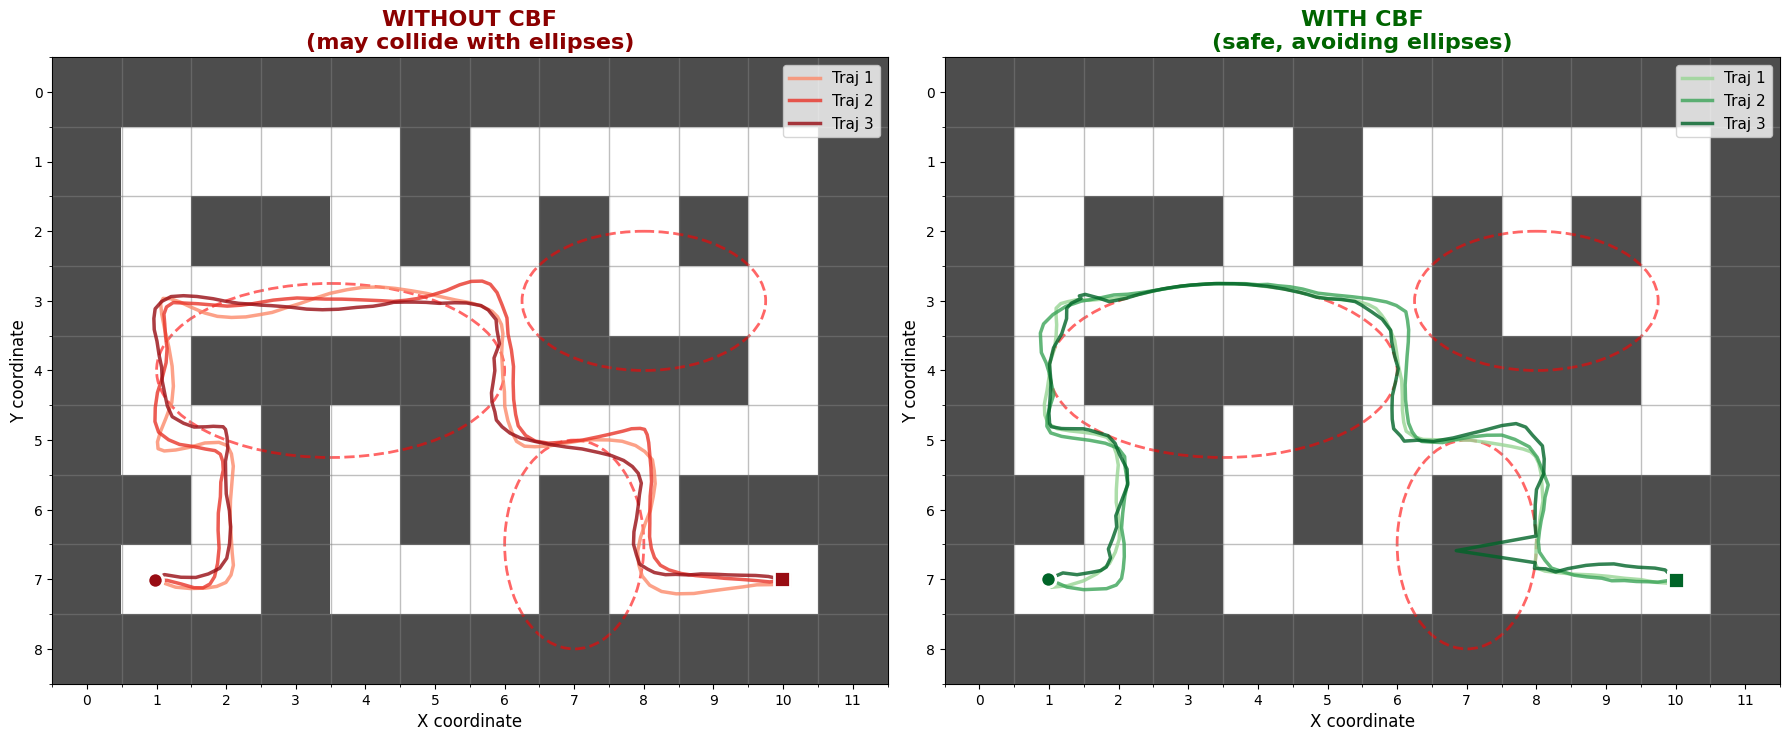


📊 Comparison saved to: /home/nvidiapc/Flow_ICLR/fmtorch/research/Maze_Experiment/edu_tutorial/results/educational_comparison_cbf.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Without CBF
create_maze_background(axes[0], show_ellipses=True)
colors_red = plt.cm.Reds(np.linspace(0.4, 0.9, len(trajs_no_cbf)))
for i, traj in enumerate(trajs_no_cbf):
    axes[0].plot(traj[:, 0], traj[:, 1], color=colors_red[i], linewidth=2.5, alpha=0.8, label=f'Traj {i+1}')
    axes[0].scatter(traj[0, 0], traj[0, 1], color=colors_red[i], s=120, marker='o', zorder=5, edgecolor='white', linewidth=2)
    axes[0].scatter(traj[-1, 0], traj[-1, 1], color=colors_red[i], s=120, marker='s', zorder=5, edgecolor='white', linewidth=2)
axes[0].set_title("WITHOUT CBF\n(may collide with ellipses)", fontsize=16, fontweight='bold', color='darkred')
axes[0].legend(fontsize=11)

# Right: With CBF
create_maze_background(axes[1], show_ellipses=True)
colors_green = plt.cm.Greens(np.linspace(0.4, 0.9, len(trajs_with_cbf)))
for i, traj in enumerate(trajs_with_cbf):
    axes[1].plot(traj[:, 0], traj[:, 1], color=colors_green[i], linewidth=2.5, alpha=0.8, label=f'Traj {i+1}')
    axes[1].scatter(traj[0, 0], traj[0, 1], color=colors_green[i], s=120, marker='o', zorder=5, edgecolor='white', linewidth=2)
    axes[1].scatter(traj[-1, 0], traj[-1, 1], color=colors_green[i], s=120, marker='s', zorder=5, edgecolor='white', linewidth=2)
axes[1].set_title("WITH CBF\n(safe, avoiding ellipses)", fontsize=16, fontweight='bold', color='darkgreen')
axes[1].legend(fontsize=11)

for ax in axes:
    ax.set_xlim(-0.5, len(LARGE_MAZE_DIVERSE_GR[0])-0.5)
    ax.set_ylim(len(LARGE_MAZE_DIVERSE_GR)-0.5, -0.5)
    ax.set_xticks(np.arange(0, len(LARGE_MAZE_DIVERSE_GR[0])))
    ax.set_yticks(np.arange(0, len(LARGE_MAZE_DIVERSE_GR)))
    ax.set_xlabel('X coordinate', fontsize=12)
    ax.set_ylabel('Y coordinate', fontsize=12)
    ax.set_aspect('equal')

plt.tight_layout()
save_path = os.path.join(cfg.FIGURE_DIR, "educational_comparison_cbf.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n📊 Comparison saved to: {save_path}")


---
## 🎓 总结与调参指南

### 恭喜！你已经完成了Flow Matching + CBF的完整学习！

---

### 🔑 关键要点回顾

1. **Flow Matching**: 通过学习速度场 $v_\theta(x, t)$ 将噪声转换为数据
2. **CBF**: 通过约束 $\nabla h \cdot v \geq -\alpha(h)$ 确保安全
3. **时间门控**: 分阶段应用CBF，早期自由演化，后期强力避障
4. **闭式投影**: 找到最近的安全速度，计算高效

---

### 🎛️ 参数调优指南

#### 场景1：轨迹穿过障碍物
**症状**: 生成的轨迹仍然与椭圆相交

**解决方案**（按优先级）：
1. ⬇️ 降低 `SUPPRESS_FRAC` (如从0.5→0.3)
   - 让CBF更早激活
2. ⬆️ 增加 `ODE_CBF_PASSES` (如从5→10)
   - 更严格的约束执行
3. ⬆️ 增大 `ODE_CBF_MARGIN` (如0.0→0.02)
   - 增加安全距离
4. ⬆️ 增大 `MASK_GATE` (确保是1.0)
   - 确保CBF完全开启

#### 场景2：轨迹过于保守/不自然
**症状**: 轨迹过度弯曲，远离障碍物

**解决方案**：
1. ⬆️ 增大 `SUPPRESS_FRAC` (如从0.5→0.7)
   - 延迟CBF激活
2. ⬇️ 降低 `ODE_CBF_PASSES` (如从5→3)
   - 减轻约束强度
3. ⬇️ 降低 `MAX_CORR_NORM` (如从1.9→1.0)
   - 限制修正幅度
4. ⬇️ 降低 `MASK_GATE` (如从1.0→0.7)
   - 减弱CBF全局强度

#### 场景3：计算太慢
**症状**: 生成轨迹耗时过长

**解决方案**：
1. ⬇️ 减少 `T_SPAN` 点数 (如从100→50)
2. ⬇️ 降低 `ODE_CBF_PASSES` (如从5→3)
3. ⬆️ 增大 `SOLVER_TOLERANCE` (如从1e-5→1e-4)
4. 切换求解器 (dopri5→rk4或euler)

#### 场景4：轨迹抖动/不平滑
**症状**: 轨迹有明显的折线或抖动

**解决方案**：
1. ⬆️ 增加 `T_SPAN` 点数 (如从100→200)
2. ⬇️ 降低 `SOLVER_TOLERANCE` (如从1e-5→1e-6)
3. ⬇️ 降低 `MAX_CORR_NORM`
4. 平滑过渡区间：增大 `RAMP_FRAC - SUPPRESS_FRAC`

---

### 🧪 建议的实验

1. **实验A: 时间门控影响**
   ```python
   for suppress in [0.3, 0.5, 0.7]:
       cfg.SUPPRESS_FRAC = suppress
       # 生成轨迹并对比
   ```

2. **实验B: CBF强度**
   ```python
   for strength in [0.5, 0.7, 1.0]:
       cfg.MASK_GATE = strength
       # 观察避障效果
   ```

3. **实验C: 障碍物数量**
   ```python
   # 添加新椭圆
   ELLIPSES.append(EllipseObstacle(5.0, 6.0, 2.5, 2.0, 0))
   # 测试CBF鲁棒性
   ```

4. **实验D: 求解器对比**
   ```python
   for method in ['euler', 'rk4', 'dopri5']:
       cfg.SOLVER_METHOD = method
       # 比较精度和速度
   ```

---

### 📚 进一步学习

**推荐资源**：
- Flow Matching论文: "Flow Matching for Generative Modeling"
- CBF理论: "Control Barrier Functions: Theory and Applications"
- ODE求解: "Numerical Methods for Ordinary Differential Equations"

**代码扩展**：
- 添加更复杂的障碍物（多边形、不规则形状）
- 实现在线CBF（实时轨迹修正）
- 多智能体协同避障

---

### 🎉 你已经掌握了：
✅ Flow Matching的完整推理流程  
✅ CBF的数学原理和实现  
✅ 时间门控策略的设计  
✅ 参数调优的方法论  
✅ 安全关键系统的实践经验  

**继续探索，创造更安全的AI系统！** 🚀
